# 1.0 — Setup & Imports
Mount Google Drive and import all required standard, third-party, and ML libraries.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Standard library
import io
import json
import os
import random
import time
from pathlib import Path

# Third-party – data / viz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from openpyxl import Workbook, load_workbook
from openpyxl.drawing.image import Image as XLImage
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

sns.set_style("whitegrid")
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 2.0 — Configuration
All hyper-parameters, paths, and architecture configs are defined here. Change values in this single cell to reconfigure the whole notebook.

In [3]:
# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────
MODEL_DIR   = Path("/content/drive/My Drive/Classification/spatialgcn/models")
RESULTS_DIR = Path("/content/drive/My Drive/Classification/spatialgcn/results")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR    = RESULTS_DIR / "training_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR     = RESULTS_DIR / "scene_visualizations"
VIS_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR   = Path("/content/drive/My Drive/Classification/data")
DATA_FILE  = DATA_DIR / "data.csv"
LABEL_FILE = DATA_DIR / "ref.csv"

# ── Dataset geometry ──────────────────────────────────────────────────
H, W, B    = 330, 307, 6          # height, width, bands
PATCH_SIZE  = 9
INNER_PATCH = 3                   # unused by SpatialGCN; kept for compatibility with shared helpers

# ── Train / val / test splits ─────────────────────────────────────────
TRAIN_PERCENT          = 0.75
VAL_SPLIT_FROM_TRAIN   = 0.20

# ── Training ──────────────────────────────────────────────────────────
BATCH_SIZE    = 128
EPOCHS        = 100
LEARNING_RATE = 3e-4
DROPOUT_RATE  = 0.25
CAPACITY_PRESET = "spatialgcn_arch"

TRAIN_CFG = {
    "label_smoothing": 0.05,
    "weight_decay":    1e-4,
    "clipnorm":        1.0,
    "cosine_alpha":    0.05,
}

# ── SpatialGCN architecture config ──────────────────────────────────────
# Treats each 9x9 patch as a fixed regular-grid graph (one node per pixel,
# 4- or 8-connected neighbours) and runs graph convolutions over it, in the
# spirit of the power-grid graph convolution used by graph-based foundation
# models for spatial-temporal data (e.g. GridFM, Hamann et al., 2024),
# applied here to a pixel-adjacency grid rather than an electrical network.
GCN_CFG = {
    "connectivity": 4,                    # 4- or 8-connected pixel neighbours
    "gcn_units":    [64, 128, 128],        # one GraphConvLayer per entry
    "dense_units":  [128, 64],             # classifier head after pooling
}

# Fallback config used when Colab runs out of memory
GCN_FALLBACK_CFG = {
    "connectivity": 4,
    "gcn_units":    [48, 96],
    "dense_units":  [96, 48],
}

# ── Visualisation palette ─────────────────────────────────────────────
CLASS_COLOR_BASE = [
    "#0000FF", "#00FF00", "#FF0000", "#00FFFF", "#FF00FF",
    "#FFFF00", "#A52A2A", "#FFA500", "#7FFF00", "#8A2BE2",
]
BACKGROUND_COLOR  = "#000000"
VIS_EXCEL_PATH    = VIS_DIR / "initial_classification_maps.xlsx"

print("Data file:    ", DATA_FILE)
print("Label file:   ", LABEL_FILE)
print("Model dir:    ", MODEL_DIR)
print("Results dir:  ", RESULTS_DIR)
print("Plot dir:     ", PLOT_DIR)
print("Arch preset:  ", CAPACITY_PRESET)

Data file:     /content/drive/My Drive/Classification/data/data.csv
Label file:    /content/drive/My Drive/Classification/data/ref.csv
Model dir:     /content/drive/My Drive/Classification/spatialgcn/models
Results dir:   /content/drive/My Drive/Classification/spatialgcn/results
Plot dir:      /content/drive/My Drive/Classification/spatialgcn/results/training_plots
Arch preset:   spatialgcn_arch


# 3.0 — Data Loading & Preprocessing
Load the raw multispectral CSV files, apply per-band min-max normalisation, extract labelled patches, and create stratified train / val / test splits.

## 3.1 — Loading and patch extraction helpers

In [4]:
def load_multispectral_6band(data_path, label_path, height, width, bands):
    """Load multispectral data and reference labels; normalise each band to [0, 1]."""
    x = pd.read_csv(data_path).to_numpy(dtype=np.float32).reshape(height, width, bands)
    y = pd.read_csv(label_path).to_numpy(dtype=np.int32).reshape(height, width)

    x_norm = np.empty_like(x, dtype=np.float32)
    for b in range(bands):
        band     = x[:, :, b]
        band_min = np.min(band)
        band_max = np.max(band)
        denom    = max(band_max - band_min, 1e-8)
        x_norm[:, :, b] = (band - band_min) / denom

    return x_norm, y


def extract_labeled_patches(x, y, patch_size=9):
    """Extract (patch_size × patch_size) spatial patches around every labelled pixel."""
    pad   = patch_size // 2
    x_pad = np.pad(x, ((pad, pad), (pad, pad), (0, 0)), mode="edge")

    coords  = np.argwhere(y > 0)
    patches = np.empty((coords.shape[0], patch_size, patch_size, x.shape[-1]), dtype=np.float32)
    labels  = np.empty((coords.shape[0],), dtype=np.int32)

    for i, (r, c) in enumerate(coords):
        patches[i] = x_pad[r:r + patch_size, c:c + patch_size, :]
        labels[i]  = int(y[r, c]) - 1  # convert class IDs to 0..C-1

    return patches, labels, coords

## 3.2 — Load data and create splits

In [5]:
x_img, y_img = load_multispectral_6band(DATA_FILE, LABEL_FILE, H, W, B)
X, y, coords = extract_labeled_patches(x_img, y_img, PATCH_SIZE)

num_classes = int(np.unique(y).size)
input_shape = (PATCH_SIZE, PATCH_SIZE, B)

print("x_img:", x_img.shape, "  y_img:", y_img.shape)
print("Labelled samples:", X.shape[0])
print("Patch tensor:    ", X.shape)
print("Num classes:     ", num_classes)

x_img: (330, 307, 6)   y_img: (330, 307)
Labelled samples: 17239
Patch tensor:     (17239, 9, 9, 6)
Num classes:      7


In [6]:
# Stratified split used by SpatialGCN
x_train_full, x_test, y_train_full, y_test = train_test_split(
    X, y,
    train_size=TRAIN_PERCENT,
    random_state=SEED,
    stratify=y,
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=VAL_SPLIT_FROM_TRAIN,
    random_state=SEED,
    stratify=y_train_full,
)

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_val_cat   = keras.utils.to_categorical(y_val,   num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

print("Train:", x_train.shape, y_train.shape)
print("Val:  ", x_val.shape,   y_val.shape)
print("Test: ", x_test.shape,  y_test.shape)

Train: (10343, 9, 9, 6) (10343,)
Val:   (2586, 9, 9, 6) (2586,)
Test:  (4310, 9, 9, 6) (4310,)


# 4.0 — Model Definitions
Defines SpatialGCN: a graph-convolutional classifier over the fixed pixel-adjacency grid of each patch. A custom Keras layer is registered for serialisation.

## 4.1 — Shared custom Keras layer: GraphConvLayer

In [7]:
@tf.keras.utils.register_keras_serializable()
class GraphConvLayer(layers.Layer):
    """Graph convolution over a fixed pixel-adjacency grid graph.

    Each pixel in the (patch_size x patch_size) patch is treated as a graph
    node, connected to its 4- or 8-connected spatial neighbours. Since every
    patch has the identical regular-grid topology, the (symmetrically
    normalised, Kipf & Welling, 2017-style) adjacency matrix is a fixed
    constant computed once at build time -- not a per-sample input. This
    mirrors the graph-convolution formulation used by graph-based foundation
    models for spatial(-temporal) data (e.g. GridFM's power-grid convolution,
    Hamann et al., 2024, Eq. 36), applied here to a pixel grid instead of an
    electrical network.
    """

    def __init__(self, patch_size, units, connectivity=4, activation="gelu", **kwargs):
        super().__init__(**kwargs)
        self.patch_size   = patch_size
        self.units        = units
        self.connectivity = connectivity
        self.activation   = keras.activations.get(activation)

    def build(self, input_shape):
        n = self.patch_size * self.patch_size
        adj = np.zeros((n, n), dtype="float32")
        for r in range(self.patch_size):
            for c in range(self.patch_size):
                idx = r * self.patch_size + c
                neighbors = [(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)]
                if self.connectivity == 8:
                    neighbors += [(r - 1, c - 1), (r - 1, c + 1), (r + 1, c - 1), (r + 1, c + 1)]
                for nr, nc in neighbors:
                    if 0 <= nr < self.patch_size and 0 <= nc < self.patch_size:
                        adj[idx, nr * self.patch_size + nc] = 1.0
        adj = adj + np.eye(n, dtype="float32")                    # self-loops
        deg = adj.sum(axis=1)
        d_inv_sqrt = np.zeros_like(deg)
        nonzero = deg > 0
        d_inv_sqrt[nonzero] = np.power(deg[nonzero], -0.5)
        norm_adj = d_inv_sqrt[:, None] * adj * d_inv_sqrt[None, :]  # symmetric normalisation

        self.norm_adj = tf.constant(norm_adj, dtype=tf.float32)     # (n, n), fixed
        self.kernel = layers.Dense(self.units, use_bias=True, name=f"{self.name}_kernel")
        super().build(input_shape)

    def call(self, node_features):
        # node_features: (batch, n_nodes, in_dim)
        aggregated = tf.einsum("ij,bjd->bid", self.norm_adj, node_features)
        return self.activation(self.kernel(aggregated))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "patch_size": self.patch_size, "units": self.units,
            "connectivity": self.connectivity,
            "activation": keras.activations.serialize(self.activation),
        })
        return cfg

## 4.2 — SpatialGCN: graph convolution over the pixel-adjacency grid

Each 9x9 patch is treated as a graph with one node per pixel and edges to its 4-connected neighbours (`GCN_CFG["connectivity"]`). A stack of `GraphConvLayer`s aggregates spectral information across this fixed grid graph, followed by global average pooling over all nodes and a small MLP classifier head.

This is a genuinely different computational paradigm from the earlier spectral-hypernetwork, hierarchical-transformer, and CLIP-style models: no attention, no wavelength conditioning, no text tower — just local graph message-passing, which is a natural fit for the strong spatial correlation between neighbouring pixels in a land-cover patch. Because the graph topology is a fixed regular grid (not a pretrained/external structure), this model is trained entirely from scratch with no external-knowledge caveat, unlike the DOFA/GeoRSCLIP-style layers built previously.

In [8]:
def build_spatial_gcn(input_shape, num_classes, dropout_rate=0.25, cfg=None):
    """Build the SpatialGCN classifier: graph convolutions over the fixed
    pixel-adjacency grid of a patch, followed by global average pooling and
    an MLP head.
    """
    cfg = cfg or GCN_CFG
    patch_h, patch_w, bands = input_shape
    assert patch_h == patch_w, "SpatialGCN assumes a square patch."

    inputs = keras.Input(shape=input_shape)
    x = layers.Reshape((patch_h * patch_w, bands), name="gcn_flatten_nodes")(inputs)  # (B, n_nodes, bands)

    for i, units in enumerate(cfg["gcn_units"], start=1):
        x = GraphConvLayer(patch_h, units, connectivity=cfg["connectivity"], name=f"gcn_layer{i}")(x)
        x = layers.Dropout(dropout_rate, name=f"gcn_drop{i}")(x)

    x = layers.GlobalAveragePooling1D(name="gcn_gap")(x)
    for i, units in enumerate(cfg["dense_units"], start=1):
        x = layers.Dense(units, activation="gelu", name=f"gcn_fc{i}")(x)
        x = layers.Dropout(dropout_rate, name=f"gcn_fc_drop{i}")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="gcn_logits")(x)
    return keras.Model(inputs, outputs, name="SpatialGCN")

# 5.0 — Training & Evaluation Helpers
Optimiser factory, learning-rate schedule, calibration metrics (Brier score, ECE), and the main `train_save_evaluate` function.

## 5.1 — Calibration metrics

In [9]:
def multiclass_brier_score(y_onehot, y_prob):
    """Compute the multiclass Brier score (mean squared error over probability vectors)."""
    return float(np.mean(np.sum((y_prob - y_onehot) ** 2, axis=1)))


def expected_calibration_error(y_true, y_prob, n_bins=15):
    """Compute Expected Calibration Error (ECE) with equal-width confidence bins."""
    confidences = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)
    correct     = (predictions == y_true).astype(np.float32)
    bin_edges   = np.linspace(0.0, 1.0, n_bins + 1)
    ece         = 0.0

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        in_bin = (confidences >= lo) & (confidences <= hi if i == n_bins - 1 else confidences < hi)
        prop   = np.mean(in_bin)
        if prop > 0:
            ece += np.abs(np.mean(correct[in_bin]) - np.mean(confidences[in_bin])) * prop

    return float(ece)

## 5.2 — Optimiser factory

In [10]:
def make_optimizer(num_train_samples):
    """Build an AdamW optimiser with a cosine-decay learning-rate schedule."""
    steps_per_epoch = int(np.ceil(num_train_samples / BATCH_SIZE))
    decay_steps     = max(1, steps_per_epoch * EPOCHS)
    lr_schedule     = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE,
        decay_steps=decay_steps,
        alpha=TRAIN_CFG["cosine_alpha"],
    )
    return keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=TRAIN_CFG["weight_decay"],
        clipnorm=TRAIN_CFG["clipnorm"],
    )

## 5.3 — Main training, saving, and evaluation function

In [11]:
def train_save_evaluate(model_name, model_builder, capacity_tag="max"):
    """Compile, train, save (best + final), and evaluate a single-head model.

    Returns a metrics dict, per-class classification report, confusion matrix,
    and the raw Keras history dict.
    """
    tf.keras.backend.clear_session()
    model      = model_builder()
    best_path  = MODEL_DIR / f"{model_name}_best.keras"
    final_path = MODEL_DIR / f"{model_name}_final.keras"

    # AdamW + cosine decay with label smoothing.
    model.compile(
        optimizer=make_optimizer(len(x_train)),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=TRAIN_CFG["label_smoothing"]),
        metrics=["accuracy"],
    )
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=str(best_path), monitor="val_loss",
            mode="min", save_best_only=True, verbose=1,
        ),
    ]
    x_tr, y_tr           = x_train, y_train_cat
    x_va, y_va           = x_val,   y_val_cat
    x_te, y_te, y_te_cat = x_test, y_test, y_test_cat
    x_eval, y_eval, y_eval_cat = x_val, y_val, y_val_cat

    train_start = time.perf_counter()
    history_obj = model.fit(
        x_tr, y_tr,
        validation_data=(x_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
        shuffle=True,
    )
    train_time_sec = float(time.perf_counter() - train_start)

    epochs_ran = int(len(history_obj.history.get("loss", [])))
    if epochs_ran != EPOCHS:
        print(f"WARNING: {model_name} ran {epochs_ran} epochs, expected {EPOCHS}.")
    else:
        print(f"{model_name} completed full training: {epochs_ran}/{EPOCHS} epochs.")

    model.save(final_path)

    y_eval_prob = model.predict(x_eval, batch_size=BATCH_SIZE, verbose=0)
    y_test_prob = model.predict(x_te,   batch_size=BATCH_SIZE, verbose=0)
    y_test_pred = np.argmax(y_test_prob, axis=1)

    report = classification_report(y_te, y_test_pred, output_dict=True, zero_division=0)
    cm     = confusion_matrix(y_te, y_test_pred)

    row = {
        "model":            model_name,
        "capacity_tag":     capacity_tag,
        "test_accuracy":    float(accuracy_score(y_te, y_test_pred)),
        "kappa":            float(cohen_kappa_score(y_te, y_test_pred)),
        "macro_f1":         float(f1_score(y_te, y_test_pred, average="macro")),
        "weighted_f1":      float(f1_score(y_te, y_test_pred, average="weighted")),
        "val_nll":          float(log_loss(y_eval, y_eval_prob, labels=np.arange(num_classes))),
        "test_nll":         float(log_loss(y_te,   y_test_prob, labels=np.arange(num_classes))),
        "val_brier":        multiclass_brier_score(y_eval_cat, y_eval_prob),
        "test_brier":       multiclass_brier_score(y_te_cat,   y_test_prob),
        "test_ece_15bin":   expected_calibration_error(y_te, y_test_prob, n_bins=15),
        "epochs_configured": int(EPOCHS),
        "epochs_ran":       epochs_ran,
        "train_time_sec":   train_time_sec,
        "best_model_path":  str(best_path),
        "final_model_path": str(final_path),
    }
    return row, report, cm, history_obj.history

# 6.0 — Model Training
Builds and trains SpatialGCN. An OOM error automatically retries with a reduced fallback config.

In [12]:
def build_gcn_with_cfg(cfg):
    """Instantiate SpatialGCN from a config dict."""
    return build_spatial_gcn(
        input_shape, num_classes,
        dropout_rate=DROPOUT_RATE,
        cfg=cfg,
    )


model_builders = {
    "SpatialGCN": lambda: build_gcn_with_cfg(GCN_CFG),
}

In [13]:
results_rows   = []
model_artifacts = {}

for model_name, builder in model_builders.items():
    print(f"\n{'=' * 25} Training {model_name} ({CAPACITY_PRESET}) {'=' * 25}")

    try:
        row, report, cm, history = train_save_evaluate(model_name, builder,
                                                       capacity_tag=CAPACITY_PRESET)
    except tf.errors.ResourceExhaustedError:
        # Automatically retry with a smaller fallback config to handle Colab OOM
        if model_name == "SpatialGCN":
            print("OOM on SpatialGCN default config. Retrying with fallback config.")
            tf.keras.backend.clear_session()
            row, report, cm, history = train_save_evaluate(
                model_name, lambda: build_gcn_with_cfg(GCN_FALLBACK_CFG),
                capacity_tag="fallback",
            )
        else:
            raise

    results_rows.append(row)
    model_artifacts[model_name] = {"report": report, "confusion_matrix": cm, "history": history}

summary_df = (
    pd.DataFrame(results_rows)
    .sort_values("test_accuracy", ascending=False)
    .reset_index(drop=True)
)
summary_df


========================= Training SpatialGCN (spatialgcn_arch) =========================
Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.4039 - loss: 1.8510
Epoch 1: val_loss improved from None to 1.54879, saving model to /content/drive/My Drive/Classification/spatialgcn/models/SpatialGCN_best.keras

Epoch 1: finished saving model to /content/drive/My Drive/Classification/spatialgcn/models/SpatialGCN_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.4190 - loss: 1.7404 - val_accuracy: 0.4242 - val_loss: 1.5488
Epoch 2/100
73/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4325 - loss: 1.5093
Epoch 2: val_loss improved from 1.54879 to 1.27814, saving model to /content/drive/My Drive/Classification/spatialgcn/models/SpatialGCN_best.keras

Epoch 2: finished saving model to /content/drive/My Drive/Classification/spatialgcn/models/SpatialGCN_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4531 - loss: 1.4435 - val_accuracy: 0.5251 - val

,model,capacity_tag,test_accuracy,kappa,macro_f1,weighted_f1,val_nll,test_nll,val_brier,test_brier,test_ece_15bin,epochs_configured,epochs_ran,train_time_sec,best_model_path,final_model_path
0,SpatialGCN,spatialgcn_arch,0.845708,0.788338,0.782528,0.843014,0.466311,0.453401,0.232072,0.224204,0.059742,100,100,82.785414,/content/drive/My Drive/Classification/spatial...,/content/drive/My Drive/Classification/spatial...


# 7.0 — Results & Metrics
Save classification summaries to CSV / JSON, then plot training curves, cross-model bar charts, calibration proxies, and confusion matrices.

## 7.1 — Save summary CSV and per-model JSON reports

In [14]:
summary_path = RESULTS_DIR / "classification_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved summary:", summary_path)

for model_name, artifact in model_artifacts.items():
    report_path = RESULTS_DIR / f"{model_name}_classification_report.json"
    with open(report_path, "w", encoding="utf-8") as f:
        json.dump(artifact["report"], f, indent=2)

print("Per-model classification reports saved to:", RESULTS_DIR)
summary_df

Saved summary: /content/drive/My Drive/Classification/spatialgcn/results/classification_summary.csv
Per-model classification reports saved to: /content/drive/My Drive/Classification/spatialgcn/results


,model,capacity_tag,test_accuracy,kappa,macro_f1,weighted_f1,val_nll,test_nll,val_brier,test_brier,test_ece_15bin,epochs_configured,epochs_ran,train_time_sec,best_model_path,final_model_path
0,SpatialGCN,spatialgcn_arch,0.845708,0.788338,0.782528,0.843014,0.466311,0.453401,0.232072,0.224204,0.059742,100,100,82.785414,/content/drive/My Drive/Classification/spatial...,/content/drive/My Drive/Classification/spatial...


## 7.2 — Training curves (accuracy and loss per epoch)

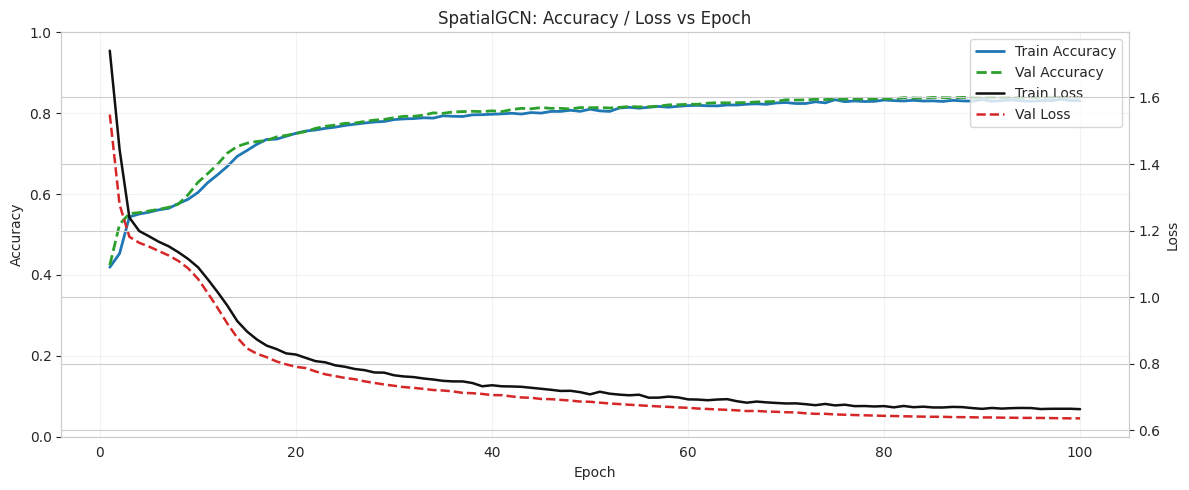

In [15]:
for model_name, artifact in model_artifacts.items():
    hist   = artifact["history"]
    epochs = np.arange(1, len(hist["loss"]) + 1)

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(epochs, hist["accuracy"],     color="#1f77b4", linewidth=2,   label="Train Accuracy")
    ax1.plot(epochs, hist["val_accuracy"], color="#2ca02c", linewidth=2, linestyle="--", label="Val Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.set_ylim(0, 1.0)
    ax1.grid(True, alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(epochs, hist["loss"],     color="#111111", linewidth=1.8,   label="Train Loss")
    ax2.plot(epochs, hist["val_loss"], color="#d62728", linewidth=1.8, linestyle="--", label="Val Loss")
    ax2.set_ylabel("Loss")

    lines  = ax1.get_lines() + ax2.get_lines()
    labels = [ln.get_label() for ln in lines]
    ax1.legend(lines, labels, loc="upper right", frameon=True)
    plt.title(f"{model_name}: Accuracy / Loss vs Epoch")
    plt.tight_layout()

    curve_path = PLOT_DIR / f"{model_name}_training_curves.png"
    plt.savefig(curve_path, dpi=200, bbox_inches="tight")
    plt.show()

## 7.3 — Cross-model comparison bar charts

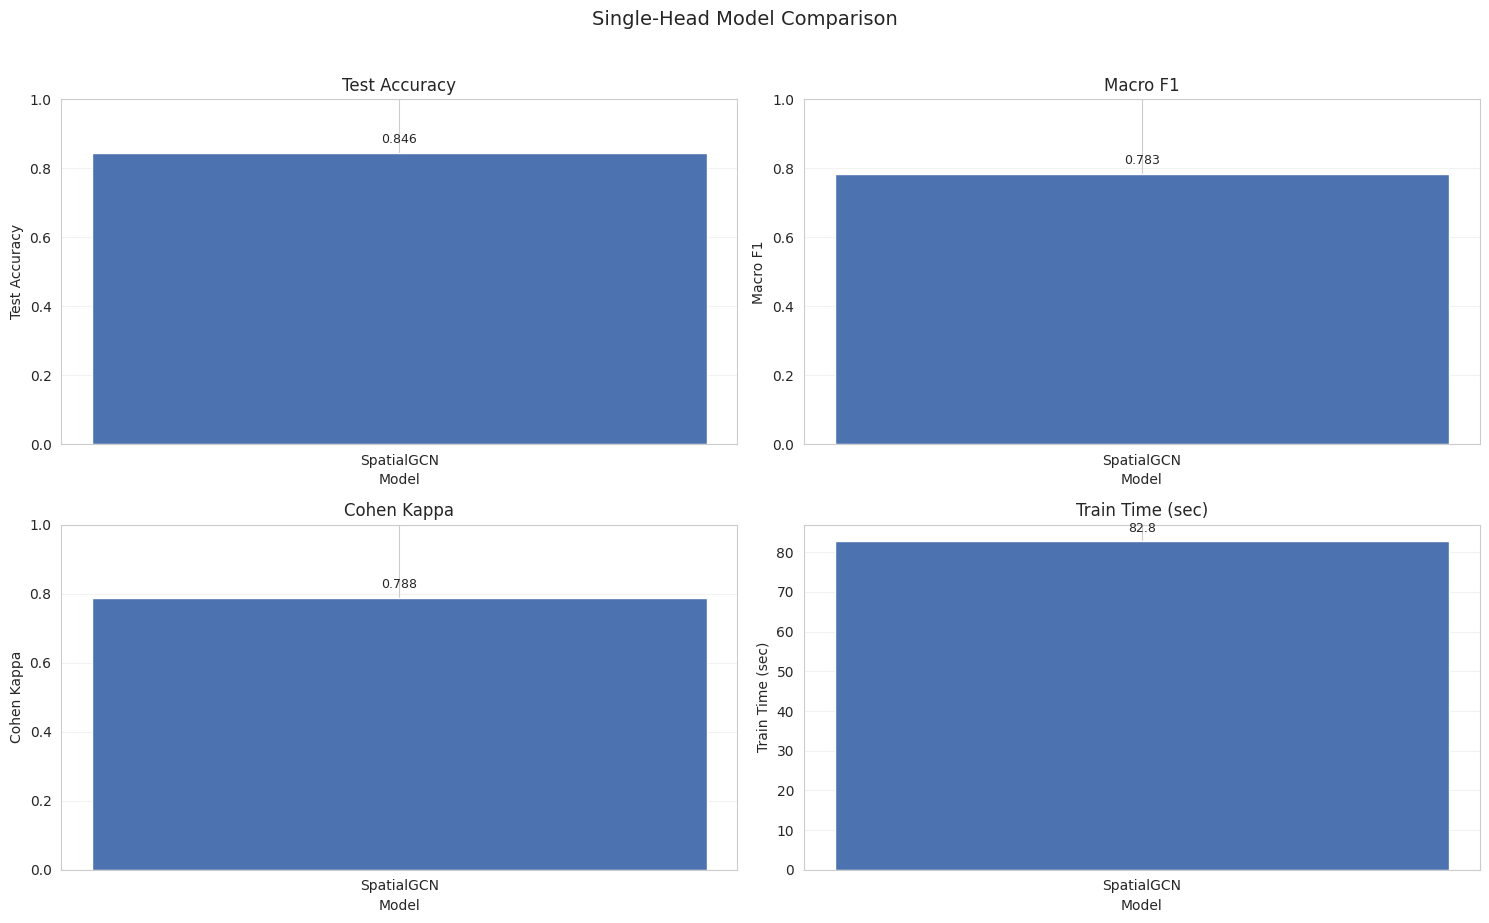

In [16]:
plot_df = summary_df[[
    "model", "test_accuracy", "macro_f1", "kappa", "train_time_sec",
    "test_nll", "test_brier", "test_ece_15bin",
]].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes    = axes.flatten()
palette = ["#4c72b0", "#55a868", "#c44e52"]

metric_specs = [
    ("test_accuracy",  "Test Accuracy",   (0.0, 1.0), "{:.3f}"),
    ("macro_f1",       "Macro F1",        (0.0, 1.0), "{:.3f}"),
    ("kappa",          "Cohen Kappa",     (0.0, 1.0), "{:.3f}"),
    ("train_time_sec", "Train Time (sec)", None,       "{:.1f}"),
]

for ax, (col, title, ylim, fmt) in zip(axes, metric_specs):
    local = plot_df[["model", col]].copy()
    bars  = ax.bar(local["model"], local[col], color=palette[:len(local)])
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.25)
    for patch in bars:
        height = patch.get_height()
        xpos   = patch.get_x() + patch.get_width() / 2
        offset = (ylim[1] - ylim[0]) * 0.02 if ylim else max(local[col].max() * 0.02, 0.05)
        ax.text(xpos, height + offset, fmt.format(height), ha="center", va="bottom", fontsize=9)

plt.suptitle("Single-Head Model Comparison", y=1.02, fontsize=14)
plt.tight_layout()
comparison_path = PLOT_DIR / "model_comparison_metrics.png"
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
plt.show()

## 7.4 — Calibration proxy metrics and confusion matrices

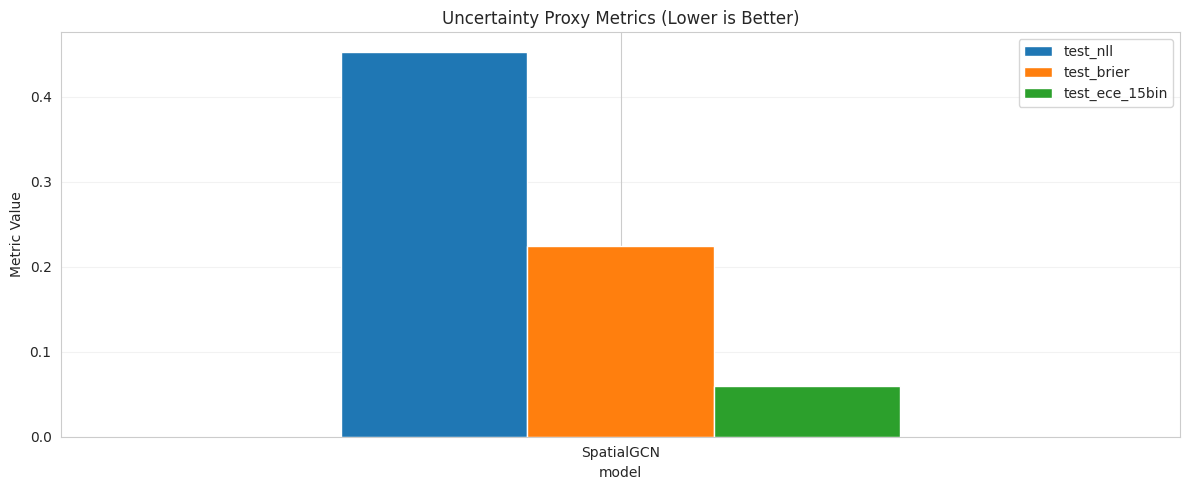

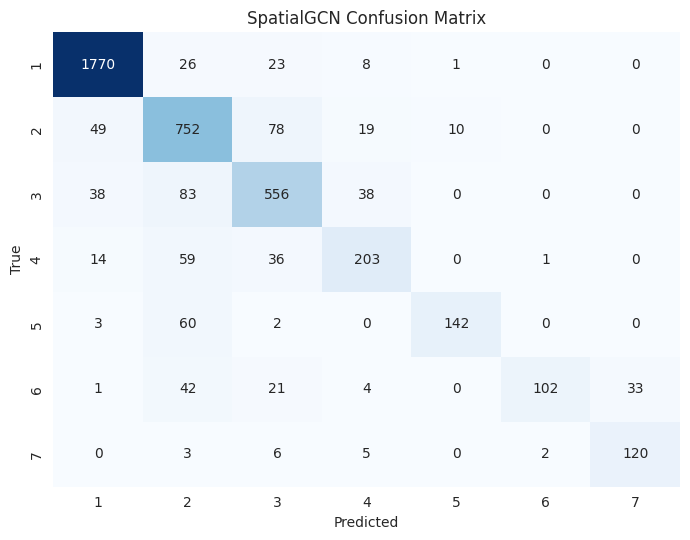

Saved confusion matrix figure: /content/drive/My Drive/Classification/spatialgcn/results/training_plots/confusion_matrices_side_by_side.png
All training plots saved to: /content/drive/My Drive/Classification/spatialgcn/results/training_plots


In [17]:
# Calibration proxy chart (lower is better for all three metrics)
fig, ax     = plt.subplots(figsize=(12, 5))
calib_cols  = ["test_nll", "test_brier", "test_ece_15bin"]
calib_df    = plot_df[["model"] + calib_cols].set_index("model")
calib_df.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Uncertainty Proxy Metrics (Lower is Better)")
ax.set_ylabel("Metric Value")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
calib_path = PLOT_DIR / "uncertainty_proxy_metrics.png"
plt.savefig(calib_path, dpi=200, bbox_inches="tight")
plt.show()

# Side-by-side confusion matrices
class_ticks = [str(i + 1) for i in range(num_classes)]
fig, axes   = plt.subplots(1, len(model_artifacts), figsize=(7 * len(model_artifacts), 5.5))
if len(model_artifacts) == 1:
    axes = [axes]

for ax, (model_name, artifact) in zip(axes, model_artifacts.items()):
    sns.heatmap(
        artifact["confusion_matrix"],
        annot=True, fmt="d", cmap="Blues",
        xticklabels=class_ticks, yticklabels=class_ticks,
        cbar=False, ax=ax,
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
cm_path = PLOT_DIR / "confusion_matrices_side_by_side.png"
plt.savefig(cm_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved confusion matrix figure:", cm_path)
print("All training plots saved to:", PLOT_DIR)

# 8.0 — Scene Visualisation
Load the saved best models, run dense patch-by-patch inference over the entire scene, and save classified maps as PNGs and an Excel workbook.

## 8.1 — Visualisation helpers

In [18]:
CUSTOM_OBJECTS = {
    "GraphConvLayer": GraphConvLayer,
}


def get_scene_rgb(x_img, bands):
    """Select three bands as an approximate RGB composite; clip to [0, 1]."""
    if bands >= 6:
        rgb_idx = [bands // 2 - 1, bands // 2, bands // 2 + 1]
    elif bands >= 3:
        rgb_idx = [0, 1, 2]
    else:
        raise ValueError(f"Need at least 3 bands to form RGB, got {bands}.")
    return np.clip(x_img[:, :, rgb_idx], 0.0, 1.0)


def get_display_cmap(num_classes):
    """Build a ListedColormap: index 0 = background black, 1..K = class colours."""
    return ListedColormap([BACKGROUND_COLOR] + CLASS_COLOR_BASE[:num_classes])


def predict_full_scene_labels(model, x_img, patch_size=9, batch_size=256):
    """Run dense sliding-window inference row-by-row; returns a (H, W) label map."""
    pad   = patch_size // 2
    x_pad = np.pad(x_img, ((pad, pad), (pad, pad), (0, 0)), mode="edge")
    preds = np.zeros((x_img.shape[0], x_img.shape[1]), dtype=np.int32)

    for r in range(x_img.shape[0]):
        row_patches = np.empty(
            (x_img.shape[1], patch_size, patch_size, x_img.shape[-1]),
            dtype=np.float32,
        )
        for c in range(x_img.shape[1]):
            row_patches[c] = x_pad[r:r + patch_size, c:c + patch_size, :]

        row_prob  = model.predict(row_patches, batch_size=batch_size, verbose=0)
        preds[r]  = np.argmax(row_prob, axis=1) + 1  # back to 1..K

    return preds


def load_saved_models_for_visualization(model_dir, custom_objects):
    """Attempt to load all three best models; return dicts of loaded and missing."""
    model_files = {
        "SpatialGCN": model_dir / "SpatialGCN_best.keras",
    }
    loaded, missing = {}, {}
    for model_key, model_path in model_files.items():
        if not model_path.exists():
            missing[model_key] = f"Missing file: {model_path}"
            continue
        try:
            loaded[model_key] = keras.models.load_model(
                model_path, custom_objects=custom_objects,
                compile=False, safe_mode=False,
            )
        except Exception as exc:
            missing[model_key] = f"Load failed: {exc}"
    return loaded, missing


def save_single_panel(image, title, save_path, cmap=None, vmin=None, vmax=None):
    """Save a single image panel as a high-DPI PNG."""
    fig, ax = plt.subplots(figsize=(8, 6))
    if cmap is None:
        ax.imshow(image)
    else:
        ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14)
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", save_path)


def save_combined_overview(rgb_image, y_true, pred_maps, missing_info, num_classes, save_path):
    """Save a five-panel side-by-side overview: RGB, GT, and one panel per model."""
    cmap   = get_display_cmap(num_classes)
    panels = [
        ("Approximate RGB",                  rgb_image,                    "rgb"),
        ("True Label Map",                   y_true,                       "label"),
        ("SpatialGCN Initial Classification", pred_maps.get("SpatialGCN"), "label"),
    ]

    fig, axes = plt.subplots(1, len(panels), figsize=(30, 7), sharex=True, sharey=True)
    for ax, (title, img, kind) in zip(axes, panels):
        ax.set_title(title, fontsize=13)
        if kind == "rgb":
            ax.imshow(img)
        elif img is None:
            ax.imshow(np.zeros_like(y_true), cmap=cmap, vmin=0, vmax=num_classes)
            key = {"SpatialGCN": "SpatialGCN"}.get(
                next((k for k in ("SpatialGCN",) if k in title), None)
            )
            ax.text(0.5, 0.5, missing_info.get(key, "Unavailable"),
                    ha="center", va="center", fontsize=10, wrap=True, transform=ax.transAxes)
        else:
            ax.imshow(img, cmap=cmap, vmin=0, vmax=num_classes)
        ax.axis("off")

    handles = [plt.Rectangle((0, 0), 1, 1, color=BACKGROUND_COLOR, label="Background")]
    for i in range(num_classes):
        handles.append(plt.Rectangle((0, 0), 1, 1, color=CLASS_COLOR_BASE[i], label=f"Class {i+1}"))
    fig.legend(handles=handles, loc="lower center", ncol=min(num_classes + 1, 8),
               bbox_to_anchor=(0.5, -0.02), frameon=True)
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", save_path)


def save_images_to_excel(excel_path, image_paths, sheet_name="Initial_Classification_Maps"):
    """Embed PNG images into an Excel workbook at fixed anchor positions."""
    if excel_path.exists():
        wb = load_workbook(excel_path)
        if sheet_name in wb.sheetnames:
            del wb[sheet_name]
        ws = wb.create_sheet(title=sheet_name)
    else:
        wb = Workbook()
        ws = wb.active
        ws.title = sheet_name

    anchors = ["A1", "J1", "A25", "J25", "A49", "J49"]
    for path, anchor in zip(image_paths, anchors):
        if path.exists():
            img        = XLImage(str(path))
            img.anchor = anchor
            ws.add_image(img)

    wb.save(excel_path)
    print("Saved Excel workbook:", excel_path)

## 8.2 — Generate and save all scene maps

Generating full-scene classified image for SpatialGCN...
SpatialGCN map shape: (330, 307)


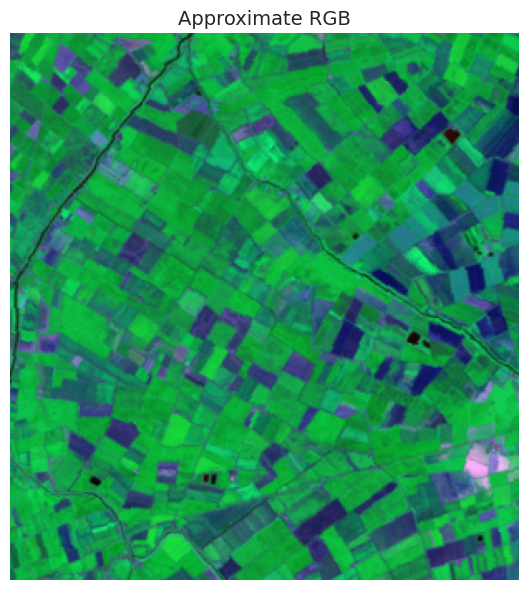

Saved: /content/drive/My Drive/Classification/spatialgcn/results/scene_visualizations/scene_rgb.png


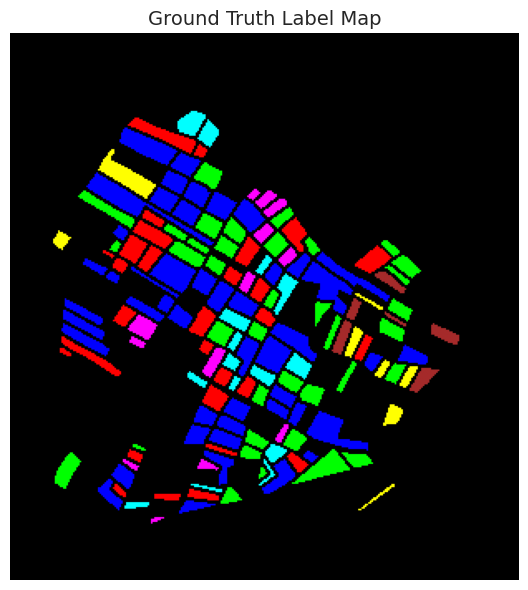

Saved: /content/drive/My Drive/Classification/spatialgcn/results/scene_visualizations/ground_truth_label_map.png


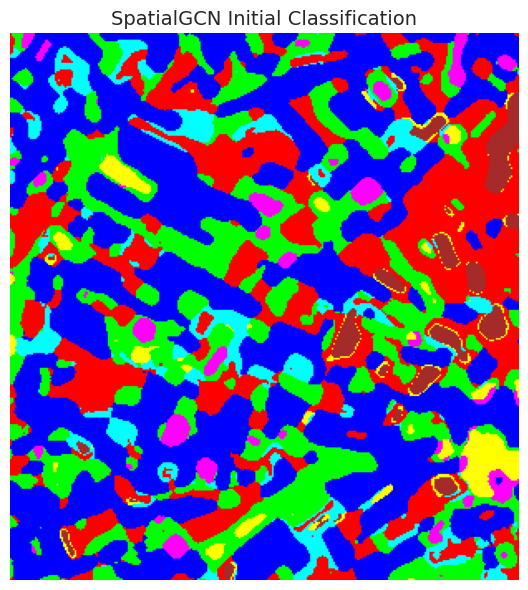

Saved: /content/drive/My Drive/Classification/spatialgcn/results/scene_visualizations/SpatialGCN_initial_classification.png


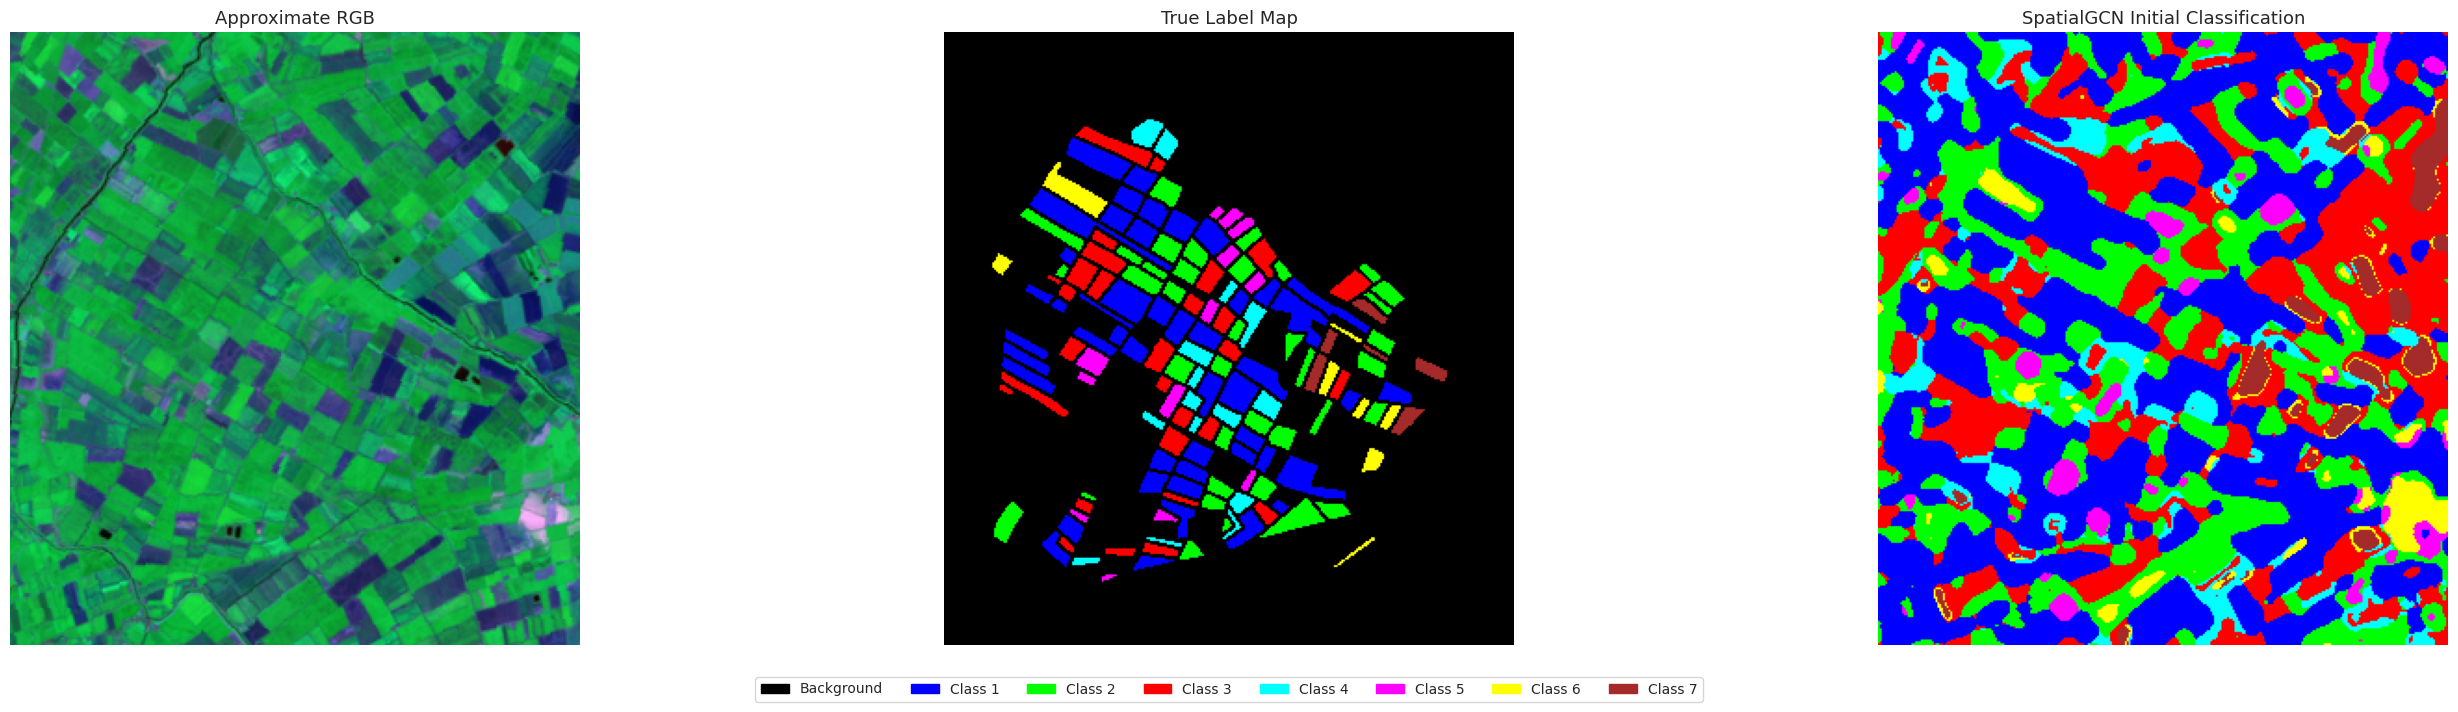

Saved: /content/drive/My Drive/Classification/spatialgcn/results/scene_visualizations/combined_initial_classification_overview.png
Saved Excel workbook: /content/drive/My Drive/Classification/spatialgcn/results/scene_visualizations/initial_classification_maps.xlsx
All visualisation outputs saved to: /content/drive/My Drive/Classification/spatialgcn/results/scene_visualizations


In [19]:
scene_rgb    = get_scene_rgb(x_img, B)
display_cmap = get_display_cmap(num_classes)

loaded_models, missing_models = load_saved_models_for_visualization(MODEL_DIR, CUSTOM_OBJECTS)
prediction_maps = {}

for model_key, loaded_model in loaded_models.items():
    print(f"Generating full-scene classified image for {model_key}...")
    prediction_maps[model_key] = predict_full_scene_labels(
        loaded_model, x_img, patch_size=PATCH_SIZE, batch_size=BATCH_SIZE,
    )
    print(f"{model_key} map shape:", prediction_maps[model_key].shape)

if missing_models:
    print("Some models could not be loaded:")
    for model_key, reason in missing_models.items():
        print(f"  - {model_key}: {reason}")

# Individual PNG paths
rgb_png      = VIS_DIR / "scene_rgb.png"
gt_png       = VIS_DIR / "ground_truth_label_map.png"
gcn_png      = VIS_DIR / "SpatialGCN_initial_classification.png"
overview_png = VIS_DIR / "combined_initial_classification_overview.png"

save_single_panel(scene_rgb, "Approximate RGB", rgb_png)
save_single_panel(y_img, "Ground Truth Label Map", gt_png, cmap=display_cmap, vmin=0, vmax=num_classes)

if prediction_maps.get("SpatialGCN") is not None:
    save_single_panel(prediction_maps["SpatialGCN"], "SpatialGCN Initial Classification",
                      gcn_png, cmap=display_cmap, vmin=0, vmax=num_classes)

save_combined_overview(
    rgb_image=scene_rgb, y_true=y_img, pred_maps=prediction_maps,
    missing_info=missing_models, num_classes=num_classes, save_path=overview_png,
)

image_paths_for_excel = [rgb_png, gt_png, gcn_png, overview_png]
save_images_to_excel(VIS_EXCEL_PATH, image_paths_for_excel, sheet_name="Initial_Classification_Maps")

print("All visualisation outputs saved to:", VIS_DIR)